In [3]:
using Random, Distributions
using Plots
using MAT
using StatsBase
using FFTW
using Roots
using Optim
# for reproducibility
Random.seed!(1);

function akde1d(X::Vector{Float64}, grid::Vector{Float64}=[0.0]; gam::Int64=0, verbose::Bool=true,
                tol::Float64=1e-5, maxit::Int64=200)
    """
        Botev's adaptive KDE for 1d. Julia reimplementation.
        --- Not fully optimized ---
        See:
            Zdravko Botev (2022). adaptive kernel density estimation in one-dimension 
            (https://www.mathworks.com/matlabcentral/fileexchange/58309-adaptive-kernel-density-estimation-in-one-dimension), 
            MATLAB Central File Exchange. Retrieved July 1, 2022.
            
            Kernel density estimation via diffusion
            Z. I. Botev, J. F. Grotowski, and D. P. Kroese (2010)
            Annals of Statistics, Volume 38, Number 5, pages 2916-2957.

        Inputs:
            X :: Vector{Float64}     -> data/samples

            (optional)
            grid :: Vector{Float64}  -> pdf mesh: defaults to 2^12 points;
                                                   boundaries are padded min/max of data
            
            (optional kwargs)
            gam  :: Int64            -> cost/accuracy tradeoff parameter, where gam<n;
                                        default value is gam=ceil(n^(1/3))+20; larger values
                                        may result in better accuracy, but always reduce speed;
                                        to speedup the code, reduce the value of "gam"; 
            verbose :: Bool          -> print iterations: default is true
            tol     :: Float64       -> relative tolerance for convergence: default is 1e-5
            maxit   :: Int64         -> Maximum iterations: default is 200

        Outputs:
            pdf  :: Vector{Float}    -> density values
            grid :: Vector{Float}    -> (spatial) mesh corresponding to pdf;
                                        equals input grid if one is provided
    """

    # Preprocessing
    n = length(X);

    MIN   = minimum(X);
    MAX   = maximum(X);
    scale = MAX - MIN;

    MAX   = MAX + 0.1*scale;
    MIN   = MIN - 0.1*scale;
    scale = MAX - MIN;

    X = (X .- MIN)/scale;

    if grid != [0.0]
        ng = length(grid);
        @assert ((ng != 0) && ((ng & (ng - 1)) == 0))    # ensure power of 2
        @assert issorted(grid)
    else
        ng = 2^12;
        @assert ((ng != 0) && ((ng & (ng - 1)) == 0))    # ensure power of 2

        grid = MIN:(scale/(ng-1)):MAX;
    end

    mesh = (grid .- MIN)/scale;

    if gam == 0
        gam = Int64(ceil(n^(1/3)) + 20);
    end
    @assert ((gam >= 1) && (gam < n))

    # Algorithm initialization
    del   = 0.2*(n^-0.2);
    mu    = X[shuffle(1:n)[1:gam]];
    w     = map(y -> y./sum(y), rand(gam));
    Sig   = (del^2).*rand(gam);
    ent   = -Inf;

    # Begin algorithm
    for iter = 1:maxit 
        
        Eold = ent;
        # update parameters
        w, mu, Sig, del, ent = kde_regEM2!(w, mu ,Sig, del, X); 
        err = abs((ent - Eold)/ent); # stopping condition

        if verbose
            println("Iter.    Tol.                      Bandwidth   \n");
            println("$iter       $err     $del        \n");
            println("------------------------------\n");
        end
        if (err < tol)
             break
        end
        if iter == maxit
            error("akde1d() alg. did not converge in maxit iterations")
        end
    end

    # Output density values at grid
    pdf = kde_probfun2(mesh, w, mu, Sig)./prod(scale); # evaluate density
    del = del*scale;                                 # adjust bw for scaling

    return (pdf, grid)
end


############################################################################################
# Utility functions for akde1d()
############################################################################################

function kde_regEM!(w, mu, Sig, del, X)
    """
    Called by akde1d()
    Update parameters
    """
    # Allocate
    gam = length(mu);
    n   = length(X);

    xRinv = zeros(n);
    xSig  = zeros(n);

    log_lh  = zeros(n, gam);
    log_sig = zeros(n, gam);

    for i = 1:gam
        xRinv .= ((X .- mu[i]).^2)./Sig[i];
        xSig  .= (xRinv./Sig[i]) .+ eps(Float64);

        log_lh[:,i]  .= -0.5*(xRinv .+ log(Sig[i]) .+ log(2.0*pi) .+ (del^2)/Sig[i]) .+ log(w[i]);
        log_sig[:,i] .= log_lh[:,i] .+ log.(xSig);
    end
    

    maxll   = maximum(log_lh, dims=2);
    maxlsig = maximum(log_sig, dims=2);

    p    = exp.(log_lh .- maxll);
    psig = exp.(log_sig .- maxlsig);

    density = sum(p, dims=2);
    psigd   = sum(psig, dims=2);
    

    log_pdf   = log.(density) .+ maxll;
    log_psigd = log.(psigd) .+ maxlsig;

    # normalize classification prob
    p .= p./density;

    # update
    ent = sum(log_pdf); 

    w  .= sum(p, dims=1)[:];

    for j = findall(w .> 0.0)
        mu[j]  = (p[:,j]'*X)./w[j];
        Sig[j] = (p[:,j]'*((X .- mu[j]).^2))./w[j] + del^2;
    end

    w   .= w/sum(w);
    curv = sum(exp.(log_psigd .- log_pdf))/n;
    del  = 1.0/(4.0*n*(4.0*pi)^(0.5)*curv)^(1.0/3.0);

    return (w, mu, Sig, del, ent)
end

function kde_regEM2!(w, mu, Sig, del, X)
    """
    Called by akde1d()
    Update parameters (vectorized code)
    """
    # Allocate
    gam = length(mu);
    n   = length(X);
    
    xRinv = repeat(X, 1, gam);
    xRinv = ((X .- mu').^2)./(Sig');
    xSig = xRinv./(Sig') .+ eps(Float64);
    log_lh = -0.5*(xRinv .+ log.(Sig') .+ log(2.0*π) .+ (del^2)./(Sig')) .+ log.(w');
    log_sig = log_lh .+ log.(xSig);

    maxll   = maximum(log_lh, dims=2);
    maxlsig = maximum(log_sig, dims=2);

    p    = exp.(log_lh .- maxll);
    psig = exp.(log_sig .- maxlsig);

    density = sum(p, dims=2);
    psigd   = sum(psig, dims=2);

    log_pdf   = log.(density) .+ maxll;
    log_psigd = log.(psigd) .+ maxlsig;

    # normalize classification prob
    p .= p./density;

    # update
    ent = sum(log_pdf); 
    w  .= sum(p, dims=1)[:];

    # find support
    supp_idx = findall(w .> 0.0);
    mu[supp_idx] .= (p[:,supp_idx]'*X)./w[supp_idx];
    X_rep = repeat(X,1,length(supp_idx));
    # (n x supp_idx)
    tmp = (p[:,supp_idx]'*((X_rep .- mu[supp_idx]').^2))./w[supp_idx]' .+ del^2;
    # does not require LinearAlgebra::diag
    Sig[supp_idx] .= map((ind)->tmp[ind,ind], supp_idx);
    
    w   .= w/sum(w);
    curv = sum(exp.(log_psigd .- log_pdf))/n;
    del  = 1.0/(4.0*n*(4.0*pi)^(0.5)*curv)^(1.0/3.0);

    return (w, mu, Sig, del, ent)
end


function kde_probfun(x, w, mu, Sig)
    """
    Called by akde1d
    Compute final distribution as a vector.
    """
    
    gam = length(mu);
    n   = length(x);

    xx  = zeros(n);
    out = zeros(n);

    for k = 1:gam
        xx  .= ((x .- mu[k]).^2)./Sig[k];
        out .= out .+ exp.(-0.5*(xx .+ log(Sig[k]) .+ log(2.0*pi)) .+ log(w[k]));
    end
    return out
end


function kde_probfun2(x, w, mu, Sig)
    """
    Called by akde1d
    Compute final distribution as a vector (vectorized code).
    """
    gam = length(mu);
    n   = length(x);

    xx  = repeat(x, 1, gam);
    xx_shifted = (xx .- mu').^2 ./ Sig';
    out = exp.(-0.5*( xx_shifted .+ log.(Sig') .+ log(2.0*π) ).+log.(w'));
    out = sum(out, dims=2);
    return out
end

kde_probfun2 (generic function with 1 method)

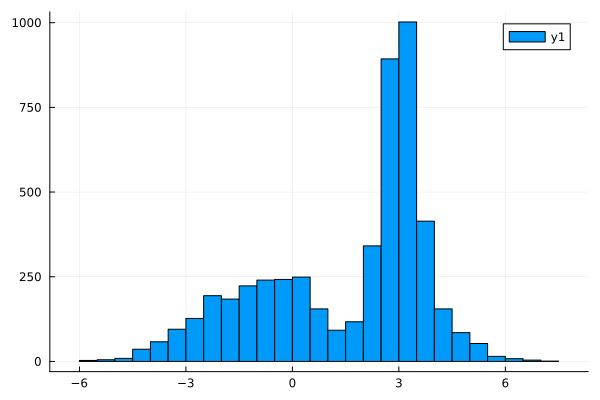

In [10]:
# mixture Gaussian distribution for testing
mixture_gaussian = MixtureModel(Normal[
   Normal(-2.0, 1.2),
   Normal(0.0, 1.0),
   Normal(3.0, 0.5),
   Normal(4.0,1)],[0.2, 0.2, 0.5, 0.1]);
# draw 1000 samples
samples = rand(mixture_gaussian, 5000);
histogram(samples, fmt=:png)

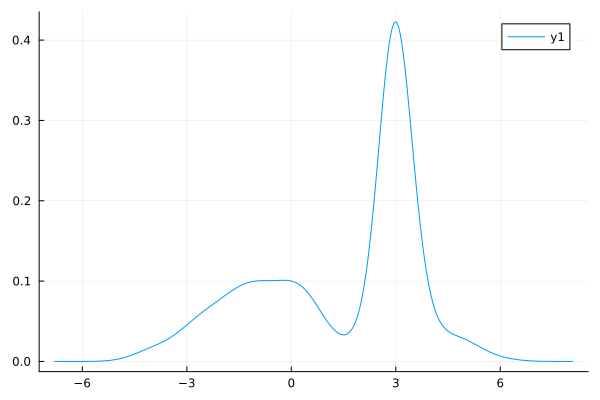

In [8]:
pp, meshgrid = akde1d(samples, verbose=false);
plot(meshgrid, pp, fmt=:png)

### Vectorizing `kde_probfun`

In [6]:
x = rand(20);
w = rand(8); mu = rand(8); Sig = rand(8);
n = length(x); gam = length(w);
compare1 = kde_probfun(x, w, mu, Sig);
compare2 = kde_probfun2(x, w, mu, Sig);
@assert sum((compare1.-compare2).^2) == 0

### Vectorizing `kde_regEM`

In [7]:
x = Vector(1:200);
w = Vector(0.5:0.5:3); mu = w.+1; Sig = mu.+2;
n = length(x);
del = 0.2*(n^-0.2);
ent = -10;
w1, mu1, Sig1, del1, ent1 = kde_regEM!(w, mu, Sig, del, x);

x = Vector(1:200);
w = Vector(0.5:0.5:3); mu = w.+1; Sig = mu.+2;
w2, mu2, Sig2, del2, ent2 = kde_regEM2!(w, mu, Sig, del, x);
@assert w1≈w2
@assert mu1≈mu2
@assert Sig1≈Sig2
@assert del1≈del2
@assert ent1≈ent2
println(sum((w1-w2).^2), "\n", sum((mu1.-mu2).^2), "\n", 
    sum((Sig1-Sig2).^2), "\n", sum((del1-del2).^2), "\n", sum((ent1-ent2).^2))

0.0
8.480254731125877e-30
8.272358328163931e-25
0.0
0.0
